# Project-2 Loan Defaulter

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns


In [2]:
df=pd.read_csv(r"C:\Data analysis\credit_risk_dataset.csv")


In [3]:
df.head()


,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1


In [4]:
df.shape


(1000, 8)

<Axes: >

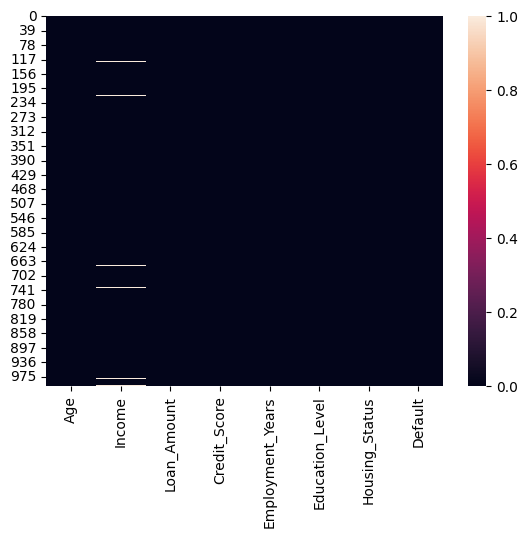

In [5]:
sns.heatmap(df.isnull())


In [6]:
df1=df.dropna()


In [7]:
df1_num_clm=df1.select_dtypes(include=['int','float'])


In [8]:
df1_cat_clm=df1.select_dtypes(include=['object'])


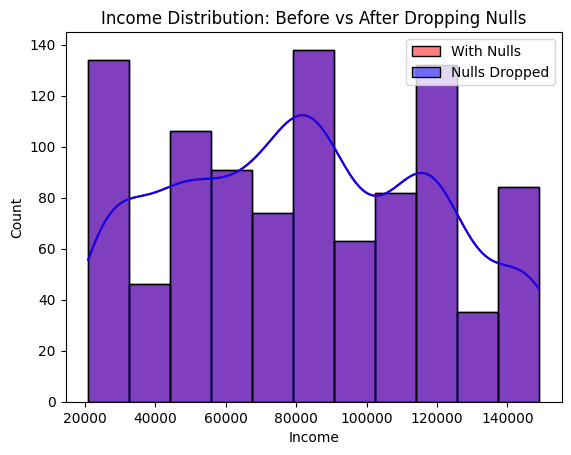

In [9]:
sns.histplot(df['Income'], color='r', kde=True, label='With Nulls')
sns.histplot(df1_num_clm['Income'], color='b', kde=True, label='Nulls Dropped')
plt.legend()
plt.title('Income Distribution: Before vs After Dropping Nulls')
plt.show()


## More EDA

In [10]:
df1.shape


(985, 8)

In [11]:
df1.describe()


,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Default
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,42.487310,82254.047716,27718.479188,581.020305,15.191878,0.137056
std,12.622171,36842.390571,12721.473641,158.550752,8.565193,0.344081
min,21.000000,20922.000000,5097.000000,300.000000,0.000000,0.000000
25%,32.000000,52154.000000,16421.000000,441.000000,8.000000,0.000000
50%,43.000000,79379.000000,28481.000000,582.000000,15.000000,0.000000
75%,53.000000,116646.000000,38453.000000,721.000000,23.000000,0.000000
max,64.000000,149038.000000,49976.000000,849.000000,29.000000,1.000000


In [12]:
# Target class balance
df1['Default'].value_counts()


Default
0    850
1    135
Name: count, dtype: int64

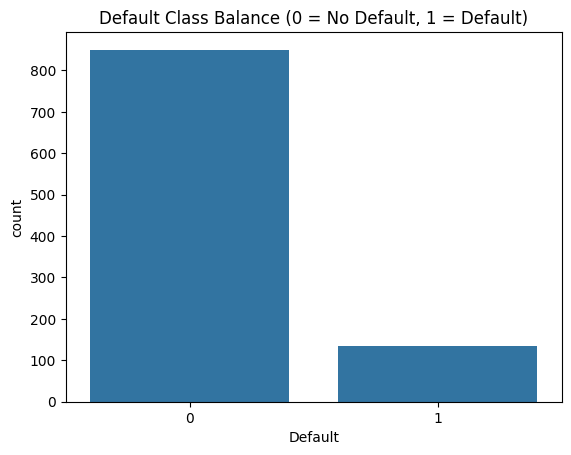

In [13]:
sns.countplot(x='Default', data=df1)
plt.title('Default Class Balance (0 = No Default, 1 = Default)')
plt.show()


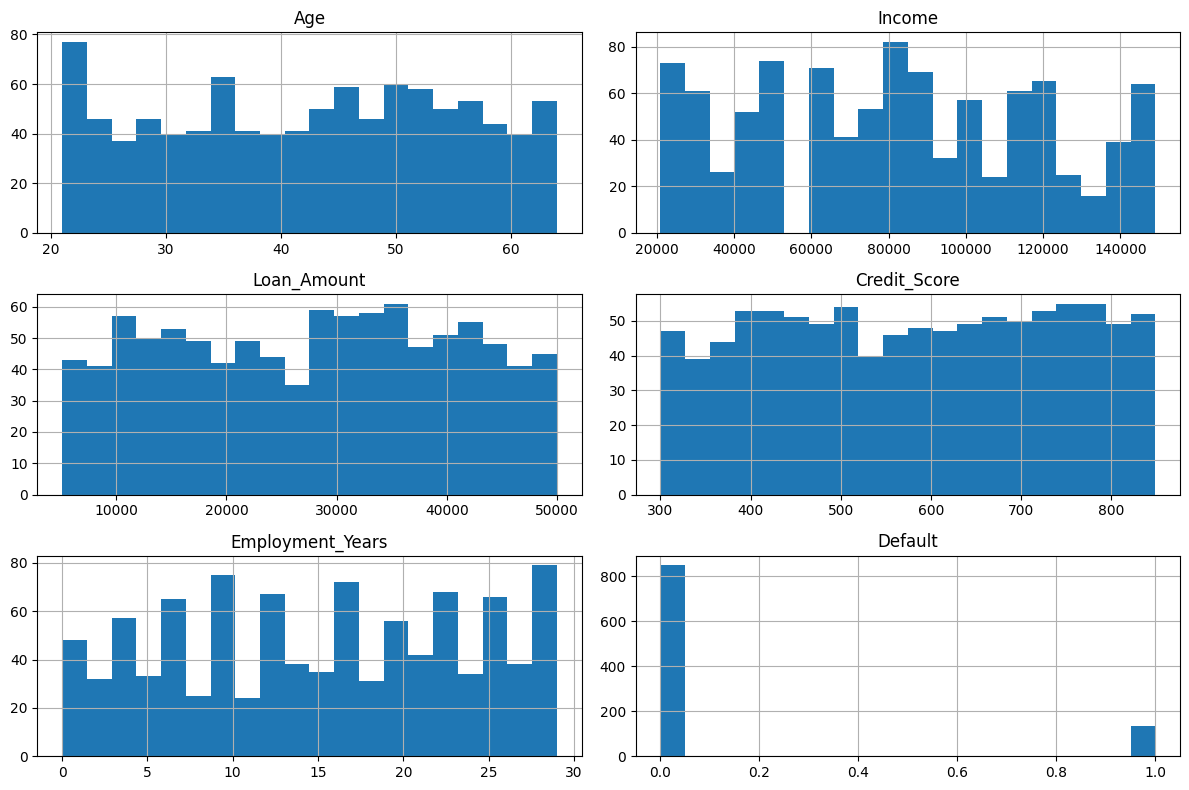

In [14]:
# Distribution of each numeric column
df1_num_clm.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


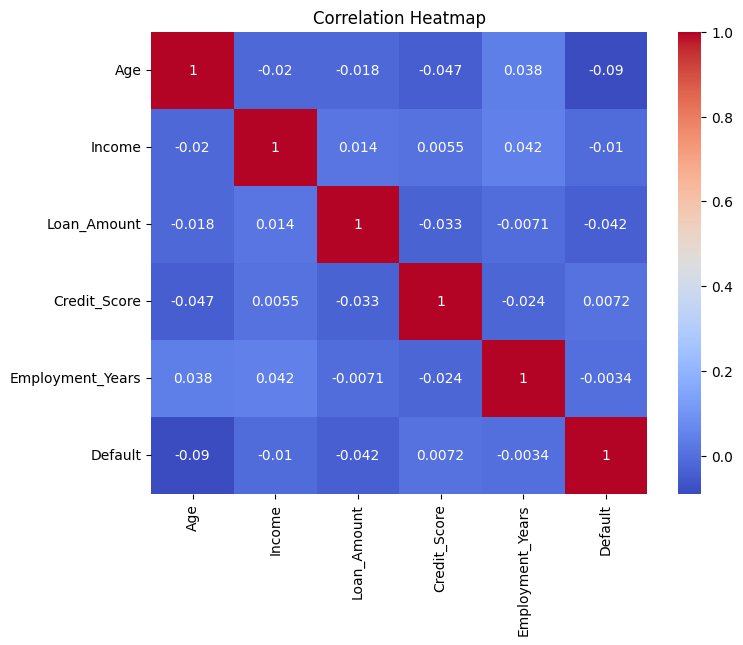

In [15]:
# Correlation between numeric features and target
plt.figure(figsize=(8, 6))
sns.heatmap(df1_num_clm.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [16]:
# Categorical columns - what values do they hold?
for col in df1_cat_clm.columns:
    print(col, ':', df1_cat_clm[col].unique())


Education_Level : ['Bachelors' 'PhD' 'Masters' 'High School']
Housing_Status : ['Own' 'Rent' 'Mortgage']


In [17]:
# Default rate split by categorical columns
for col in df1_cat_clm.columns:
    print(df1.groupby(col)['Default'].mean())
    print()


Education_Level
Bachelors      0.134694
High School    0.112069
Masters        0.152000
PhD            0.147287
Name: Default, dtype: float64

Housing_Status
Mortgage    0.134897
Own         0.135385
Rent        0.141066
Name: Default, dtype: float64



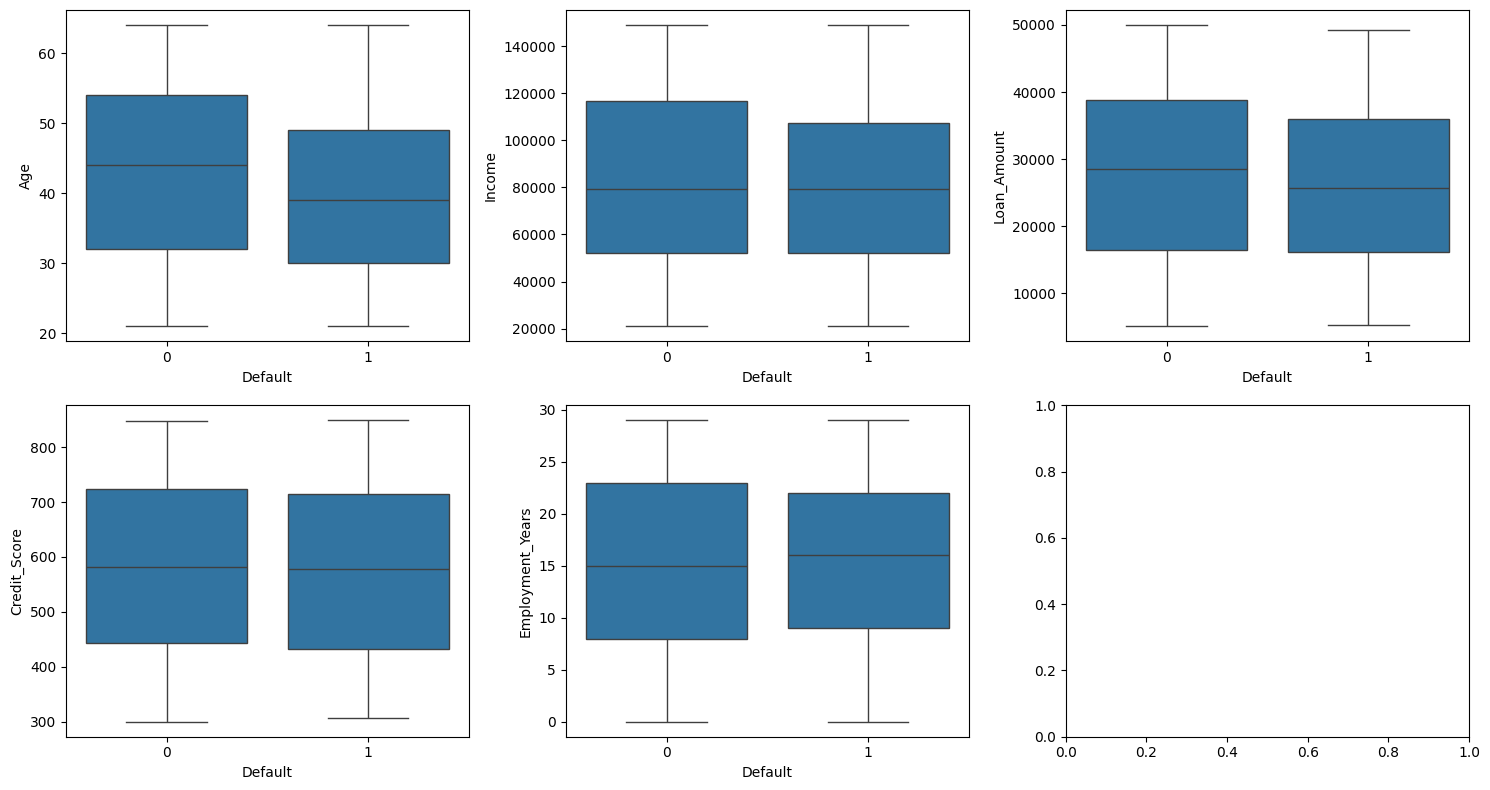

In [18]:
# Boxplots: numeric features vs Default, to spot outliers / separation
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(df1_num_clm.drop(columns=['Default']).columns):
    sns.boxplot(x='Default', y=col, data=df1, ax=axes[i])
plt.tight_layout()
plt.show()


## Preprocessing

In [19]:
# One-hot encode categorical columns
df1_cat_encoded = pd.get_dummies(df1_cat_clm, drop_first=True)
df1_cat_encoded.head()


,Education_Level_High School,Education_Level_Masters,Education_Level_PhD,Housing_Status_Own,Housing_Status_Rent
0,False,False,False,True,False
1,False,False,True,True,False
2,False,True,False,True,False
3,False,False,False,False,True
4,False,True,False,True,False


In [20]:
# Combine numeric + encoded categorical columns into final modeling dataframe
df_final = pd.concat([df1_num_clm, df1_cat_encoded], axis=1)
df_final.head()


,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Default,Education_Level_High School,Education_Level_Masters,Education_Level_PhD,Housing_Status_Own,Housing_Status_Rent
0,59,52154.0,11276,823,15,0,False,False,False,True,False
1,49,116646.0,43663,315,5,0,False,False,True,True,False
2,35,61157.0,18994,428,8,1,False,True,False,True,False
3,63,52154.0,28499,408,26,0,False,False,False,False,True
4,28,148876.0,28040,832,3,1,False,True,False,True,False


In [21]:
X = df_final.drop(columns=['Default'])
y = df_final['Default']
X.shape, y.shape


((985, 10), (985,))

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape


((788, 10), (197, 10))

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Modeling

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression')
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('ROC AUC :', roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression
Accuracy: 0.4720812182741117
ROC AUC : 0.4359477124183006
              precision    recall  f1-score   support

           0       0.84      0.48      0.61       170
           1       0.12      0.44      0.19        27

    accuracy                           0.47       197
   macro avg       0.48      0.46      0.40       197
weighted avg       0.74      0.47      0.55       197



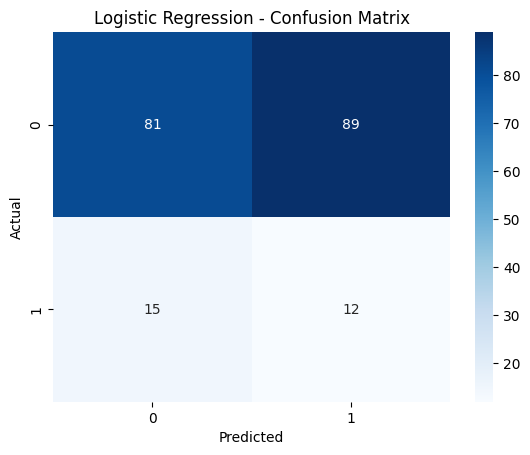

In [25]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)  # tree models don't need scaled features

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print('ROC AUC :', roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest
Accuracy: 0.7411167512690355
ROC AUC : 0.4638344226579521
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       170
           1       0.12      0.15      0.14        27

    accuracy                           0.74       197
   macro avg       0.49      0.49      0.49       197
weighted avg       0.76      0.74      0.75       197



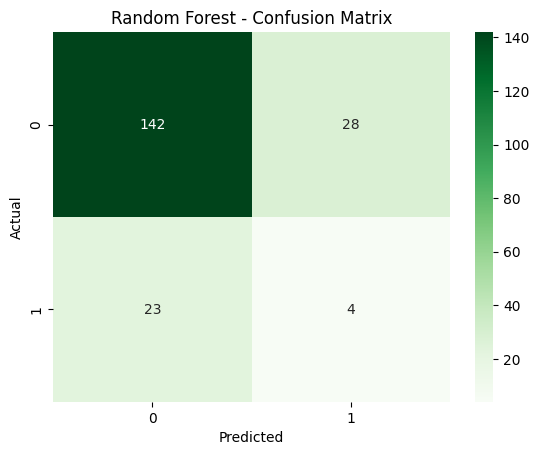

In [27]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()


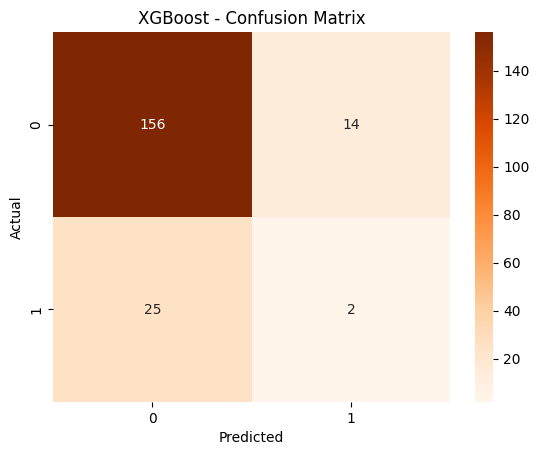

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost - Confusion Matrix')
plt.show()


## Model Comparison

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)],
    'ROC AUC': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_xgb)]
})
results


,Model,Accuracy,ROC AUC
0,Logistic Regression,0.472081,0.435948
1,Random Forest,0.842640,0.437255
2,XGBoost,0.802030,0.519826


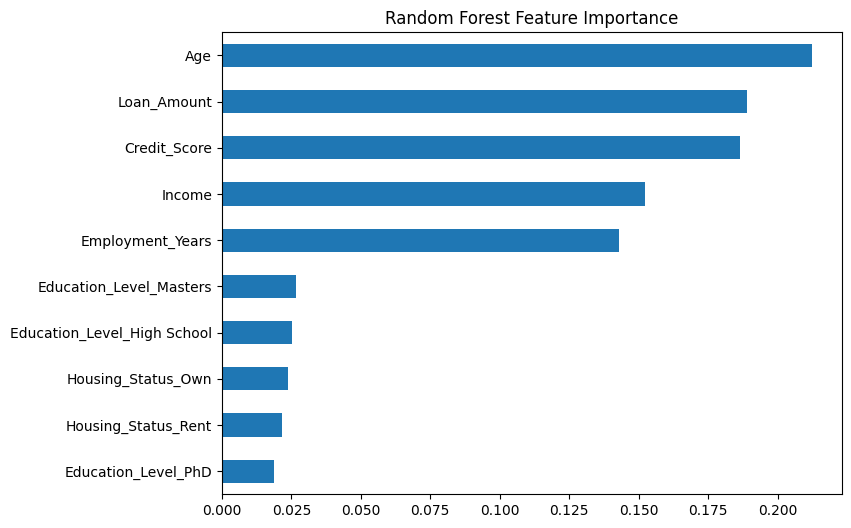

In [ ]:
# Feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='barh', figsize=(8, 6))
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()
